# Apresentação: Pipeline de Features
Este notebook carrega e apresenta os resultados gerados pelo pipeline de extração de features.
Paths usados assumem o ambiente do compose: `/workspace/data/output/features.parquet`.

In [1]:
# Imports e configurações iniciais
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageDraw, ImageFont
from io import BytesIO
sns.set(style="whitegrid")
%matplotlib inline


In [2]:
# Parâmetros de caminho
IMAGES_DIR = '/workspace/data/images'
FEATURES_PARQUET = '/workspace/data/output/features/features_raw_parquet'
METADATA_PATH = '/workspace/data/metadata_consolidated.csv'
print('IMAGES_DIR =', IMAGES_DIR)
print('FEATURES_PARQUET =', FEATURES_PARQUET)


IMAGES_DIR = /workspace/data/images
FEATURES_PARQUET = /workspace/data/output/features/features_raw_parquet


## Checagens rápidas

In [3]:
# Verificar existência dos arquivos esperados
print('Images dir exists:', os.path.isdir(IMAGES_DIR))
print('Features parquet exists:', os.path.isfile(FEATURES_PARQUET))
print('Metadata exists:', os.path.isfile(METADATA_PATH))
# listar algumas imagens
if os.path.isdir(IMAGES_DIR):
    imgs = os.listdir(IMAGES_DIR)[:10]
    print('Exemplos de imagens:', imgs)


Images dir exists: True
Features parquet exists: False
Metadata exists: True
Exemplos de imagens: ['bonehurtingjuice', 'sadcringe', 'terriblefacebookmemes', 'absolutelynotme_irl', 'memes', 'youdontsurf', 'blackpeopletwitter', 'ComedyCemetery', 'AntiMeme', 'dankmemes']


## Carregar features.parquet

In [4]:
import pandas as pd
import os
def load_parquet_path(path):
    try:
        df = pd.read_parquet(path)
        return df
    except Exception as e:
        if os.path.isdir(path):
            try:
                import pyarrow.dataset as ds
                import pyarrow as pa
                dataset = ds.dataset(path, format="parquet")
                table = dataset.to_table()  
                return table.to_pandas()
            except Exception as e2:
                raise RuntimeError(f"Failed reading partitioned parquet using pyarrow: {e2}") from e2
        raise
try:
    df = load_parquet_path(FEATURES_PARQUET)
    print('Linhas:', len(df), 'Imagens únicas:', df['image_id'].nunique() if 'image_id' in df.columns else 'n/a')
    display(df.head())
except Exception as e:
    print('Erro ao carregar parquet:', e)


Linhas: 17780 Imagens únicas: n/a


,path,filename,features_json,subreddit
0,file:/workspace/data/images/2meirl4meirl/783xe...,783xedai13ac1.png,"[{""image_path"": ""file:/workspace/data/images/2...",2meirl4meirl
1,file:/workspace/data/images/2meirl4meirl/lfdm3...,lfdm33lqh88c1.png,"[{""image_path"": ""file:/workspace/data/images/2...",2meirl4meirl
2,file:/workspace/data/images/2meirl4meirl/h34yh...,h34yh5zk177c1.jpeg,"[{""image_path"": ""file:/workspace/data/images/2...",2meirl4meirl
3,file:/workspace/data/images/2meirl4meirl/12ybv...,12ybvx80i88c1.png,"[{""image_path"": ""file:/workspace/data/images/2...",2meirl4meirl
4,file:/workspace/data/images/2meirl4meirl/zd7kp...,zd7kp5zr8wac1.jpeg,"[{""image_path"": ""file:/workspace/data/images/2...",2meirl4meirl


In [5]:
df['features_json'].head().tolist()

['[{"image_path": "file:/workspace/data/images/2meirl4meirl/783xedai13ac1.png", "detection_id": 0, "label": "person", "conf": 0.310648649930954, "bbox": [1, 1211, 738, 2460], "ocr_text": "", "ocr_global_text": "", "embedding": [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.

## Resumo estatístico e contagens

Total images (input df): 17780
Total detection rows produced: 40970
detection_type
person          19154
<<NA>>           7955
tie              1267
chair             806
car               683
clock             632
cup               628
dog               573
bottle            535
book              522
cat               446
cell phone        444
kite              409
teddy bear        389
bird              365
sports ball       343
dining table      336
laptop            283
bowl              277
cake              276
tv                264
potted plant      258
donut             197
bed               188
horse             165
couch             158
vase              147
sandwich          138
truck             137
wine glass        131
bench             126
umbrella          117
pizza             110
handbag           104
banana            104
apple              97
toilet             96
airplane           95
surfboard          95
refrigerator       95
Name: count, dtype: int64


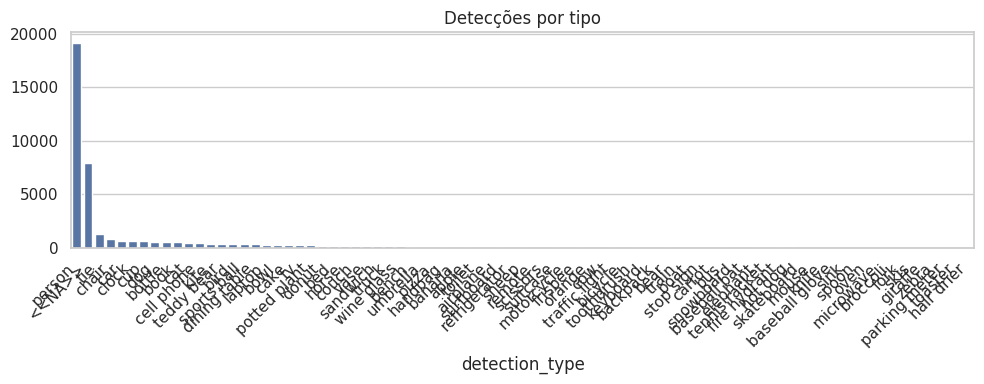

In [6]:
# Célula robusta para extrair contagens por tipo de detecção a partir de features_json
import json, pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
def iter_detections_from_cell(fj):
    """
    Normaliza uma célula features_json para um iterável de dicts.
    Lida com:
     - lista de dicts
     - string JSON -> loads
     - dict com chave 'detections' ou 'results' contendo lista
     - outros formatos (retorna elemento bruto como {'detection_value': v})
    """
    if fj is None:
        return []
    if isinstance(fj, str):
        try:
            obj = json.loads(fj)
        except Exception:
            try:
                obj = eval(fj)
            except Exception:
                return []
    else:
        obj = fj
    # possível estruturas:
    if isinstance(obj, dict):
        # dict contendo lista sob chaves comuns
        for k in ('detections','results','items','features'):
            if k in obj and isinstance(obj[k], (list,tuple)):
                return list(obj[k])
        # maybe a single dict that is itself a detection
        return [obj]
    elif isinstance(obj, (list,tuple, np.ndarray)):
        return list(obj)
    else:
        # primitive
        return [ {'detection_value': obj} ]
# detect common keys to map to detection_type
PREFERRED_TYPE_KEYS = ['detection_type','class','label','name','type','category']
def detection_type_from_dict(d):
    if not isinstance(d, dict):
        return None
    for k in PREFERRED_TYPE_KEYS:
        if k in d and d[k] not in (None, ''):
            return d[k]
    # sometimes the class is nested: {'yolo':{'class':'cat'}} or metadata -> try shallow search
    for v in d.values():
        if isinstance(v, dict):
            for k in PREFERRED_TYPE_KEYS:
                if k in v and v[k] not in (None, ''):
                    return v[k]
    return None
# Build det_df by scanning features_json
rows = []
sample_unmatched = []
for _, r in df[['filename','features_json','subreddit','path']].iterrows():
    dets = iter_detections_from_cell(r['features_json'])
    if not dets:
        continue
    for d in dets:
        out = {
            'filename': r['filename'],
            'image_id': (r['filename'].rsplit('.',1)[0] if isinstance(r['filename'], str) else None),
            'subreddit': r.get('subreddit'),
            'path': r.get('path'),
        }
        if isinstance(d, dict):
            out.update(d)
        else:
            out['detection_value'] = d
        rows.append(out)
        # capture sample if no type could be inferred
        if detection_type_from_dict(d) is None:
            sample_unmatched.append((r['filename'], d))
# DataFrame of detections
det_df = pd.DataFrame(rows)
# If needed, create/alias detection_type column
if 'detection_type' not in det_df.columns:
    for alias in ('class','label','name','type','category'):
        if alias in det_df.columns:
            det_df = det_df.rename(columns={alias: 'detection_type'})
            break
# If still missing, try to populate detection_type by scanning dict values
if 'detection_type' not in det_df.columns:
    det_df['detection_type'] = det_df.apply(lambda row: detection_type_from_dict(row) if isinstance(row.to_dict(), dict) else None, axis=1)
# Now compute counts robustly
counts = None
if 'detection_type' in det_df.columns and det_df['detection_type'].notna().any():
    counts = det_df['detection_type'].fillna('<<NA>>').value_counts()
elif 'detection_value' in det_df.columns and det_df['detection_value'].notna().any():
    counts = det_df['detection_value'].astype(str).value_counts()
else:
    counts = pd.Series(dtype=int)
# Output results
print('Total images (input df):', len(df))
print('Total detection rows produced:', len(det_df))
if not counts.empty:
    print(counts.head(40))
    plt.figure(figsize=(10,4))
    sns.barplot(x=counts.index.astype(str), y=counts.values)
    plt.xticks(rotation=45, ha='right')
    plt.title('Detecções por tipo')
    plt.tight_layout()
    plt.show()
else:
    print('Nenhuma coluna detection_type/detection_value encontrada após normalização.')
    print('Colunas de det_df:', list(det_df.columns))
    if sample_unmatched:
        print('\\nExemplos de detecções sem detection_type (mostrando até 5):')
        import pprint
        for fn, d in sample_unmatched[:5]:
            print('---', fn)
            pprint.pprint(d)

## Amostras visuais: imagens com caixas e labels

In [7]:
from matplotlib.patches import Rectangle
def show_image_with_boxes(image_path, detections):
    img = Image.open(image_path).convert('RGB')
    plt.figure(figsize=(6,6))
    fig,ax = plt.subplots(1,1,figsize=(6,6))
    ax.imshow(img)
    for det in detections:
        if not isinstance(det, dict):
            continue
        bbox = det.get('bbox') or det.get('box')
        label = det.get('label') or det.get('detection_type') or ''
        if bbox is None:
            continue
        # bbox esperado: [x1,y1,x2,y2] ou [x,y,w,h]
        if len(bbox)==4:
            x1,y1,x2,y2 = bbox
            w = x2-x1
            h = y2-y1
        else:
            x1,y1,w,h = bbox
        rect = Rectangle((x1,y1), w, h, linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, max(0,y1-6), str(label), color='yellow', fontsize=8, backgroundcolor='black')
    plt.axis('off')
    plt.show()

# Mostrar até 6 imagens com suas detecções
sample_ids = df['image_id'].drop_duplicates().tolist()[:6] if 'image_id' in df.columns else []
for img_id in sample_ids:
    row_dets = df[df['image_id']==img_id].to_dict(orient='records')
    img_path = os.path.join(IMAGES_DIR, img_id) if os.path.isfile(os.path.join(IMAGES_DIR, img_id)) else None
    if img_path:
        print('Image:', img_id)
        show_image_with_boxes(img_path, row_dets)
    else:
        print('Imagem não encontrada em IMAGES_DIR:', img_id)


## OCR: tabela de exemplos

In [8]:
# Mostrar exemplos de OCR (se coluna 'ocr_text' existir)
if 'ocr_text' in df.columns:
    ocr_df = df[['image_id','ocr_text','ocr_confidence','bbox']].dropna(subset=['ocr_text']).head(20)
    display(ocr_df)
else:
    print('Coluna ocr_text não encontrada')


Coluna ocr_text não encontrada


## Embeddings: redução de dimensionalidade e visualização

In [9]:
# Converter coluna 'embedding' para matriz e rodar PCA + TSNE (se disponível)
if 'embedding' in df.columns:
    embs = np.stack(df['embedding'].apply(lambda x: np.array(x, dtype=np.float32)))
    print('embs shape', embs.shape)
    from sklearn.decomposition import PCA
    from sklearn.manifold import TSNE
    pca = PCA(n_components=50)
    embs_pca = pca.fit_transform(embs)
    tsne = TSNE(n_components=2, init='pca', random_state=42, perplexity=30)
    embs_2d = TSNE(n_components=2, init='pca', random_state=42, perplexity=30).fit_transform(embs_pca)
    plot_df = pd.DataFrame({'x':embs_2d[:,0],'y':embs_2d[:,1]})
    if 'detection_type' in df.columns:
        plot_df['type'] = df['detection_type'].values
    plt.figure(figsize=(8,6))
    sns.scatterplot(data=plot_df, x='x', y='y', hue='type' if 'detection_type' in plot_df.columns else None, s=10, alpha=0.7)
    plt.title('Embeddings (PCA50 -> t-SNE)')
    plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
    plt.show()
else:
    print('Coluna embedding não encontrada')


Coluna embedding não encontrada


## Busca semântica de exemplo (nearest neighbors)

In [10]:
# Demonstração de busca por texto usando sentence-transformers (se instalado)
try:
    from sentence_transformers import SentenceTransformer
    model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
    def semantic_search(query, topk=5):
        qv = model.encode([query])[0] / np.linalg.norm(model.encode([query])[0])
        E = embs / np.linalg.norm(embs, axis=1, keepdims=True)
        sims = (E @ qv).astype(np.float32)
        idx = np.argsort(-sims)[:topk]
        return idx, sims[idx]
    # exemplo
    if 'embedding' in df.columns:
        idxs, scores = semantic_search('exemplo de teste')
        print('Top resultados:')
        display(df.iloc[idxs][['image_id','ocr_text']])
except Exception as e:
    print('Não foi possível executar busca semântica:', e)


/opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
I0000 00:00:1781201381.639186    2990 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781201381.780190    2990 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781201385.446545    2990 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point roun

## Próximos passos / exportação

In [11]:
# Exportar subset para anotação humana
out_csv = '/workspace/data/output/text_samples_for_annotation.csv'
if 'ocr_text' in df.columns:
    df[df['detection_type']=='text'][['image_id','ocr_text','ocr_confidence']].head(500).to_csv(out_csv, index=False)
    print('Exportado', out_csv)
else:
    print('Nada exportado (ocr_text não disponível)')


Nada exportado (ocr_text não disponível)


In [12]:
print('columns:', list(df.columns))
print('rows:', len(df))
# show first 5 features_json previews (type + short preview)
for i, v in enumerate(df['features_json'].head(5)):
    print('--- row', i, 'type', type(v))
    s = v if not isinstance(v, str) else v[:500] + ('...' if len(v)>500 else '')
    print(s)

columns: ['path', 'filename', 'features_json', 'subreddit']
rows: 17780
--- row 0 type <class 'str'>
[{"image_path": "file:/workspace/data/images/2meirl4meirl/783xedai13ac1.png", "detection_id": 0, "label": "person", "conf": 0.310648649930954, "bbox": [1, 1211, 738, 2460], "ocr_text": "", "ocr_global_text": "", "embedding": [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...
--- row 1 type <class 'str'>
[{"image_path": "file:/workspace/data/images/2meirl4meirl/lfdm33lqh88c1.png", "detection_id": 0, "label": "person", "conf": 0.8620692491531372, "bbox": [170, 227, 1216, 1258], "ocr_text": "", "ocr_global_text": "", "embedding": [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.

In [13]:
import json
def has_detections(fj):
    if not fj: return False
    if isinstance(fj, str):
        try:
            obj = json.loads(fj)
        except Exception:
            return False
    else:
        obj = fj
    # detect list-of-detections or dict-with-key
    if isinstance(obj, list) and len(obj)>0:
        # ensure first element is a dict with keys like 'label' or 'bbox' or 'error'
        return isinstance(obj[0], dict) and ('label' in obj[0] or 'bbox' in obj[0] or 'error' in obj[0])
    if isinstance(obj, dict):
        return any(k in obj for k in ('detections','results','features'))
    return False
total = len(df)
nonempty = df['features_json'].apply(lambda v: bool(v) and not (isinstance(v,float) and pd.isna(v))).sum()
det_rows = df['features_json'].apply(lambda v: has_detections(v)).sum()
print('total rows', total, 'non-empty features_json', nonempty, 'rows that parse as detections', det_rows)

total rows 17780 non-empty features_json 17780 rows that parse as detections 17780
